# Plots & Reproduction Guide

This notebook generates the plots in *"Phenomenological constraints on QCD transport with quantified theory uncertainties"* ([arXiv:2509.19759](https://arxiv.org/abs/2509.19759)).  
It uses **precomputed MCMC chains** located in `mcmc_data/`.

## Quick start
1. Install Python environment from `arXiv_2509.19759/environment.yml`
2. Activate the environment: `conda activate md`
3. Open this notebook and run all cells. (Precomputed MCMC chains are already saved in `mcmc_data/`)
4. Figures are shown inline and will be saved as pdf in `plots/` directory.

## Re-running Bayesian inference (optional)
If you want to regenerate the chains from scratch (computationally expensive):
```bash
python3 run_Grad.py
python3 run_CE.py

In [1]:
import os, sys

src_dir = os.path.abspath(os.path.join(os.getcwd(), "../..", "src"))
sys.path.append(src_dir)
emu_dir = os.path.abspath(os.path.join(os.getcwd(), "./emulators"))
sys.path.append(emu_dir)

from plot_scripts import setup_rc_params
setup_rc_params(fontsize=13)
from plot_scripts_heavyion import plot_eta_zeta, plot_model_param, plot_obs

import numpy as np
import matplotlib.pyplot as plt
import corner

from pathlib import Path
import json


In [2]:
experimental_data = np.loadtxt('./experimental_data/PbPb2760_exp_data.txt')

bin_file = json.loads(Path("./experimental_data/PbPb2760_bins.json").read_text())
obs_bins = {k: np.array(item["data"], dtype=item["dtype"]) for k, item in bin_file.items()}
# print({k: v.shape[0] for k, v in obs_bins.items()})

obs_labels = {
    'dNch_deta'      : r'$dN_{ch}/d\eta$',
    'dET_deta'       : r'$dE_T/d\eta$',
    'dN_dy_pion'     : r'$dN_{\pi}/dy$',
    'dN_dy_kaon'     : r'$dN_{k}/dy$',
    'dN_dy_proton'   : r'$dN_{p}/dy$',
    'mean_pT_pion'   : r'$\langle p_T \rangle_{\pi}$',
    'mean_pT_kaon'   : r'$\langle p_T \rangle_{k}$',
    'mean_pT_proton' : r'$\langle p_T \rangle_{p}$',
    'pT_fluct'       : r'$\delta p_T/\langle p_T \rangle$',
    'v22'            : r'$v_2\{2\}$',
    'v32'            : r'$v_3\{2\}$',
    'v42'            : r'$v_4\{2\}$'
}

allparam_lab = [r'$N$', r'$p$', r'$\sigma_k$', r'$w\,({\rm fm})$', r'$d^3_{\rm min}\,({\rm fm}^3)$', r'$\tau_R\,({\rm fm}/c)$', r'$\alpha$', 
                r'$T_{\rm kink}\,({\rm GeV})$', r'$a_{\rm low}\,({\rm GeV}^{-1})$', r'$a_{\rm high}\,({\rm GeV}^{-1})$', r'$(\eta/s)_{\rm kink}$',
                r'$(\zeta/s)_{\rm max}$', r'$T_{\zeta}\,({\rm GeV})$', r'$w_{\zeta}\,({\rm GeV})$', r'$\lambda_{\zeta}$',
                r'$b_\pi$', r'$T_{\rm sw}\, ({\rm GeV})$']

model_param_bounds = np.loadtxt('./emulators/PbPb2760/param_range.dat', delimiter=",", dtype=float, skiprows=1, usecols=(1, 2))

# make directory to save figures
os.makedirs("plots", exist_ok=True)

##  Some defs

In [3]:
def eta_over_s(T, param):
    T_kink, alow, ahigh, etas_kink = param[0], param[1], param[2], param[3]
    if T < T_kink:
        y = etas_kink + alow * (T - T_kink)
    else:
        y = etas_kink + ahigh * (T - T_kink)
    return max(y, 0)  # Ensure non-negative
# ------------------------------------

def zeta_over_s(T, param):
    zmax, T_zeta, w_zeta, lambda_zeta = param[0], param[1], param[2], param[3]
    DeltaT = T - T_zeta
    sign = 1 if DeltaT>0 else -1
    Lambda = w_zeta * (1.0 + (lambda_zeta * sign))
    x = DeltaT / Lambda
    return zmax / ( 1.0 + x**2)
# ------------------------------------

# Define function for general beta priors 
def log_prior_param(param, alpha_val, beta_val, param_min, param_max):
    """
    Log prior for parameter based on a Beta distribution.
    """
    scale = param_max - param_min  # Rescaling factor

    if param_min < param < param_max:
        # Rescale param to the range [param_min, param_max]
        param_rescaled = (param - param_min) / scale
        
        prior = beta.pdf(param_rescaled, alpha_val, beta_val) / scale
        return np.log(prior)
    else:
        return -np.inf
# ------------------------------------

# Define a list of log_prior functions for model parameters
log_prior_theta = [
    lambda param, i=i: log_prior_param(
        param, alpha_val=1.01, beta_val=1.01,  # for flat priors
        param_min=model_param_bounds[i][0], param_max=model_param_bounds[i][1]
    )
    for i in range(len(model_param_bounds))
]
# ------------------------------------


# Calibration with all observable 

## without MD

/Users/jaiswal/Desktop/git/ModelDiscrepancy/projects/arXiv_2509.19759/plot_scripts_heavyion.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/jaiswal/Desktop/git/ModelDiscrepancy/projects/arXiv_2509.19759/plot_scripts_heavyion.py:133: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


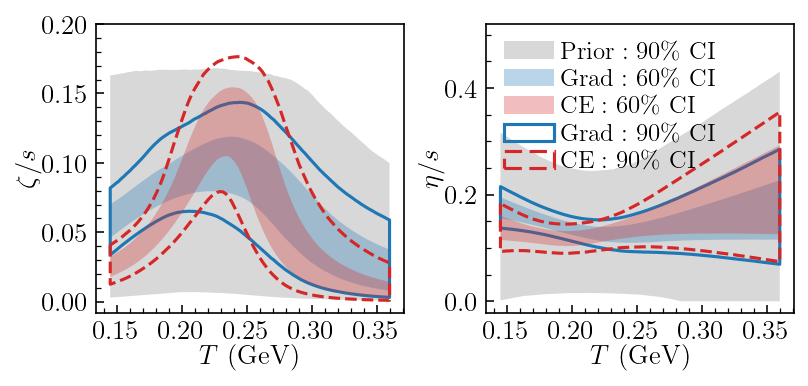

In [4]:
colors = ['tab:blue', 'tab:red']     # 'tab:orange'
linestyle = ['-', '--']
labels = [r"$\mathrm{Grad:}\ 60\%\ \mathrm{CI}$", r"$\mathrm{CE:}\ 60\%\ \mathrm{CI}$",
          r"$\mathrm{Grad:}\ 90\%\ \mathrm{CI}$", r"$\mathrm{CE:}\ 90\%\ \mathrm{CI}$"]

samples_wo_MD_Grad = np.load(f'mcmc_data/PbPb2760/Grad/all_obs/wo_MD/pocomc_chain_40000.npy') #1
samples_wo_MD_CE = np.load(f'mcmc_data/PbPb2760/CE/all_obs/wo_MD/pocomc_chain_40000.npy') #2

# slice to get samples for eta
amin, amax = 7, 11    # eta param : 7:11
param_bounds_eta = model_param_bounds[amin:amax]

samples1 = samples_wo_MD_Grad[:, amin:amax]
samples2 = samples_wo_MD_CE[:, amin:amax]
samples_eta = [samples1, samples2]

# slice to get samples for zeta
amin, amax = 11, 15   # zeta param : 11:15
param_bounds_zeta = model_param_bounds[amin:amax]

samples1 = samples_wo_MD_Grad[:, amin:amax]
samples2 = samples_wo_MD_CE[:, amin:amax]
samples_zeta = [samples1, samples2]

plot_eta_zeta(samples_eta=samples_eta, samples_zeta=samples_zeta, 
              eta_s=eta_over_s, zeta_s=zeta_over_s, 
              param_bounds_eta=param_bounds_eta, param_bounds_zeta=param_bounds_zeta, 
              colors=colors, labels=labels, linestyle=linestyle, fig_name='plots/eta_zeta_woMD.pdf')


/Users/jaiswal/Desktop/git/ModelDiscrepancy/projects/arXiv_2509.19759/plot_scripts_heavyion.py:221: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()# (rect=[0, 0, 1, 0.95])
/Users/jaiswal/Desktop/git/ModelDiscrepancy/projects/arXiv_2509.19759/plot_scripts_heavyion.py:221: UserWarning: The figure layout has changed to tight
  plt.tight_layout()# (rect=[0, 0, 1, 0.95])


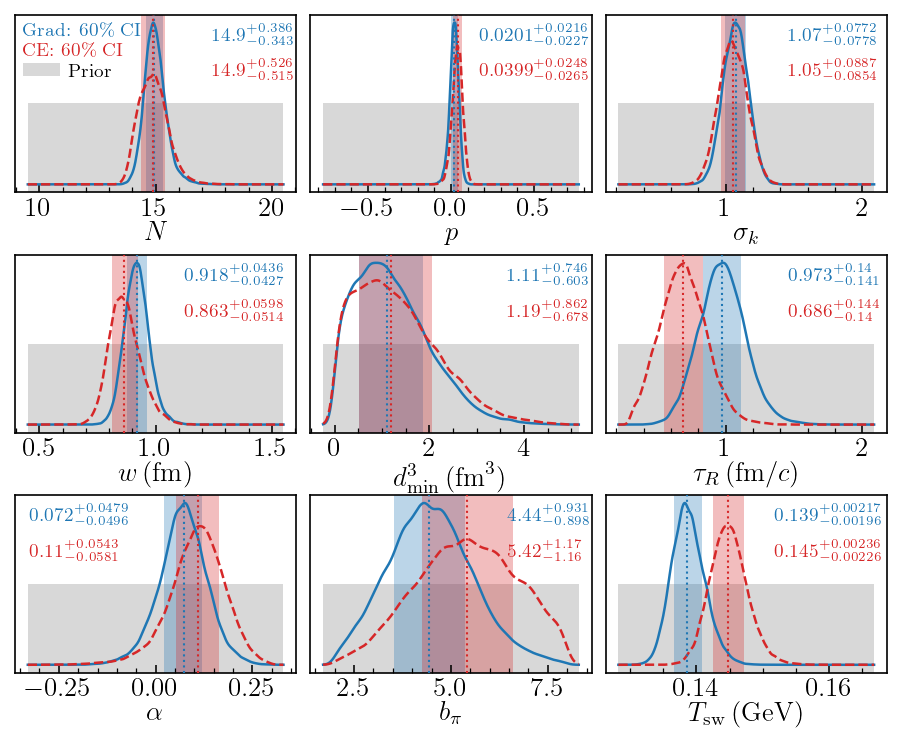

In [5]:
delta = model_param_bounds[:, 1] - model_param_bounds[:, 0]
# Extend the bounds by 5% on each side
extended_bounds = np.column_stack((
    model_param_bounds[:, 0] - 0.05 * delta,
    model_param_bounds[:, 1] + 0.05 * delta
))

samples = [samples_wo_MD_Grad, samples_wo_MD_CE]
mod_param_index = [0,1,2,3,4,5,6,15,16]

param_lab = [r'$N$', r'$p$', r'$\sigma_k$', r'$w\,({\rm fm})$', r'$d^3_{\rm min}\,({\rm fm}^3)$', 
             r'$\tau_R\,({\rm fm}/c)$', r'$\alpha$', r'$b_\pi$', r'$T_{\rm sw}\, ({\rm GeV})$']

plot_model_param(samples=samples, mod_param_index=mod_param_index, model_param_bounds=extended_bounds,
                 param_lab=param_lab, colors=colors, linestyle=linestyle, labels=labels, fig_name = 'plots/param_woMD.pdf')


In [6]:
# # corner plots ---->

# figure = corner.corner(
#     samples_wo_MD_Grad,
#     labels=allparam_lab,          # optional: parameter labels
#     quantiles=[0.16, 0.5, 0.84],  # show median + 1σ credible interval
#     show_titles=True,             # show mean/σ above diagonal plots
#     title_fmt=".3f",              # formatting for the stats
#     color="tab:blue",             # color for histograms
#     # bins=30,                    # number of bins
#     smooth=1.0,                   # KDE smoothing
# )

# figure.savefig("plots/corner_Grad_woMD.pdf", bbox_inches="tight", dpi=100)
# plt.show()

# figure = corner.corner(
#     samples_wo_MD_CE,
#     labels=allparam_lab,          # optional: parameter labels
#     quantiles=[0.16, 0.5, 0.84],  # show median + 1σ credible interval
#     show_titles=True,             # show mean/σ above diagonal plots
#     title_fmt=".3f",              # formatting for the stats
#     color="tab:red",              # color for histograms
#     # bins=30,                    # number of bins
#     smooth=1.0,                   # KDE smoothing
# )

# figure.savefig("plots/corner_CE_woMD.pdf", bbox_inches="tight", dpi=100)
# plt.show()


## with MD

/Users/jaiswal/Desktop/git/ModelDiscrepancy/projects/arXiv_2509.19759/plot_scripts_heavyion.py:133: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/jaiswal/Desktop/git/ModelDiscrepancy/projects/arXiv_2509.19759/plot_scripts_heavyion.py:133: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


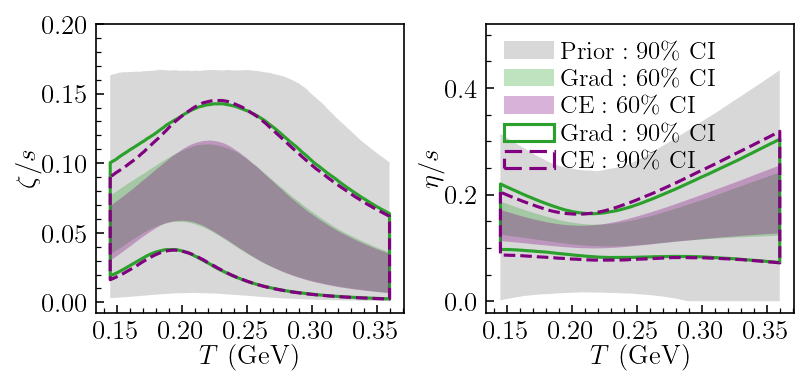

In [7]:
colors = ['tab:green', '#800080']     # 'tab:orange' 
linestyle = ['-', '--']
labels = [r"$\mathrm{Grad:}\ 60\%\ \mathrm{CI}$", r"$\mathrm{CE:}\ 60\%\ \mathrm{CI}$",
          r"$\mathrm{Grad:}\ 90\%\ \mathrm{CI}$", r"$\mathrm{CE:}\ 90\%\ \mathrm{CI}$"]

samples_w_MD_Grad = np.load(f'mcmc_data/PbPb2760/Grad/all_obs/w_MD/pocomc_chain_40000.npy') #1
samples_w_MD_CE = np.load(f'mcmc_data/PbPb2760/CE/all_obs/w_MD/pocomc_chain_40000.npy') #2

# slice to get samples for eta
amin, amax = 7, 11    # eta param : 7:11
param_bounds_eta = model_param_bounds[amin:amax]

samples1 = samples_w_MD_Grad[:, amin:amax]
samples2 = samples_w_MD_CE[:, amin:amax]
samples_eta = [samples1, samples2]

# slice to get samples for zeta
amin, amax = 11, 15   # zeta param : 11:15
param_bounds_zeta = model_param_bounds[amin:amax]

samples1 = samples_w_MD_Grad[:, amin:amax]
samples2 = samples_w_MD_CE[:, amin:amax]
samples_zeta = [samples1, samples2]

plot_eta_zeta(samples_eta=samples_eta, samples_zeta=samples_zeta, 
              eta_s=eta_over_s, zeta_s=zeta_over_s, 
              param_bounds_eta=param_bounds_eta, param_bounds_zeta=param_bounds_zeta, 
              colors=colors, labels=labels, linestyle=linestyle, fig_name='plots/eta_zeta_wMD.pdf')


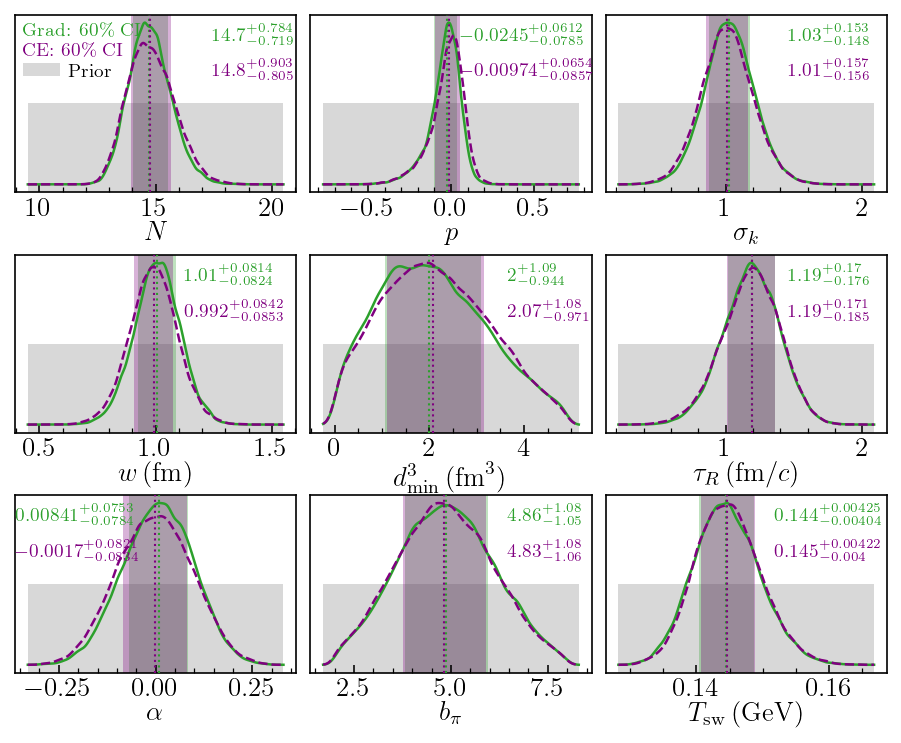

In [8]:
delta = model_param_bounds[:, 1] - model_param_bounds[:, 0]
# Extend the bounds by 5% on each side
extended_bounds = np.column_stack((
    model_param_bounds[:, 0] - 0.05 * delta,
    model_param_bounds[:, 1] + 0.05 * delta
))

samples = [samples_w_MD_Grad, samples_w_MD_CE]
mod_param_index = [0,1,2,3,4,5,6,15,16]

pos = [0.7, 0.533, 0.65, 0.6, 0.7, 0.65, 0.0, 0.7, 0.6]

param_lab = [r'$N$', r'$p$', r'$\sigma_k$', r'$w\,({\rm fm})$', r'$d^3_{\rm min}\,({\rm fm}^3)$', 
             r'$\tau_R\,({\rm fm}/c)$', r'$\alpha$', r'$b_\pi$', r'$T_{\rm sw}\, ({\rm GeV})$']

plot_model_param(samples=samples, mod_param_index=mod_param_index, model_param_bounds=extended_bounds,
                 param_lab=param_lab, colors=colors, linestyle=linestyle, labels=labels, fig_name = 'plots/param_wMD.pdf', pos=pos)


In [9]:
# # Corner plots for model parameters --> 

# figure = corner.corner(
#     samples_w_MD_Grad[:,:17],
#     labels=allparam_lab,          # optional: parameter labels
#     quantiles=[0.16, 0.5, 0.84],  # show median + 1σ credible interval
#     show_titles=True,             # show mean/σ above diagonal plots
#     title_fmt=".3f",              # formatting for the stats
#     color="tab:green",            # color for histograms
#     # bins=30,                    # number of bins
#     smooth=1.0,                   # KDE smoothing
# )

# figure.savefig("plots/corner_Grad_wMD.pdf", bbox_inches="tight", dpi=100)
# plt.show()

# figure = corner.corner(
#     samples_w_MD_CE[:,:17],
#     labels=allparam_lab,          # optional: parameter labels
#     quantiles=[0.16, 0.5, 0.84],  # show median + 1σ credible interval
#     show_titles=True,             # show mean/σ above diagonal plots
#     title_fmt=".3f",              # formatting for the stats
#     color="#800080",              # color for histograms
#     # bins=30,                    # number of bins
#     smooth=1.0,                   # KDE smoothing
# )

# figure.savefig("plots/corner_CE_wMD.pdf", bbox_inches="tight", dpi=100)
# plt.show()


## Plot observable predictions

/Users/jaiswal/Desktop/git/ModelDiscrepancy/projects/arXiv_2509.19759/plot_scripts_heavyion.py:324: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/Users/jaiswal/Desktop/git/ModelDiscrepancy/projects/arXiv_2509.19759/plot_scripts_heavyion.py:324: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


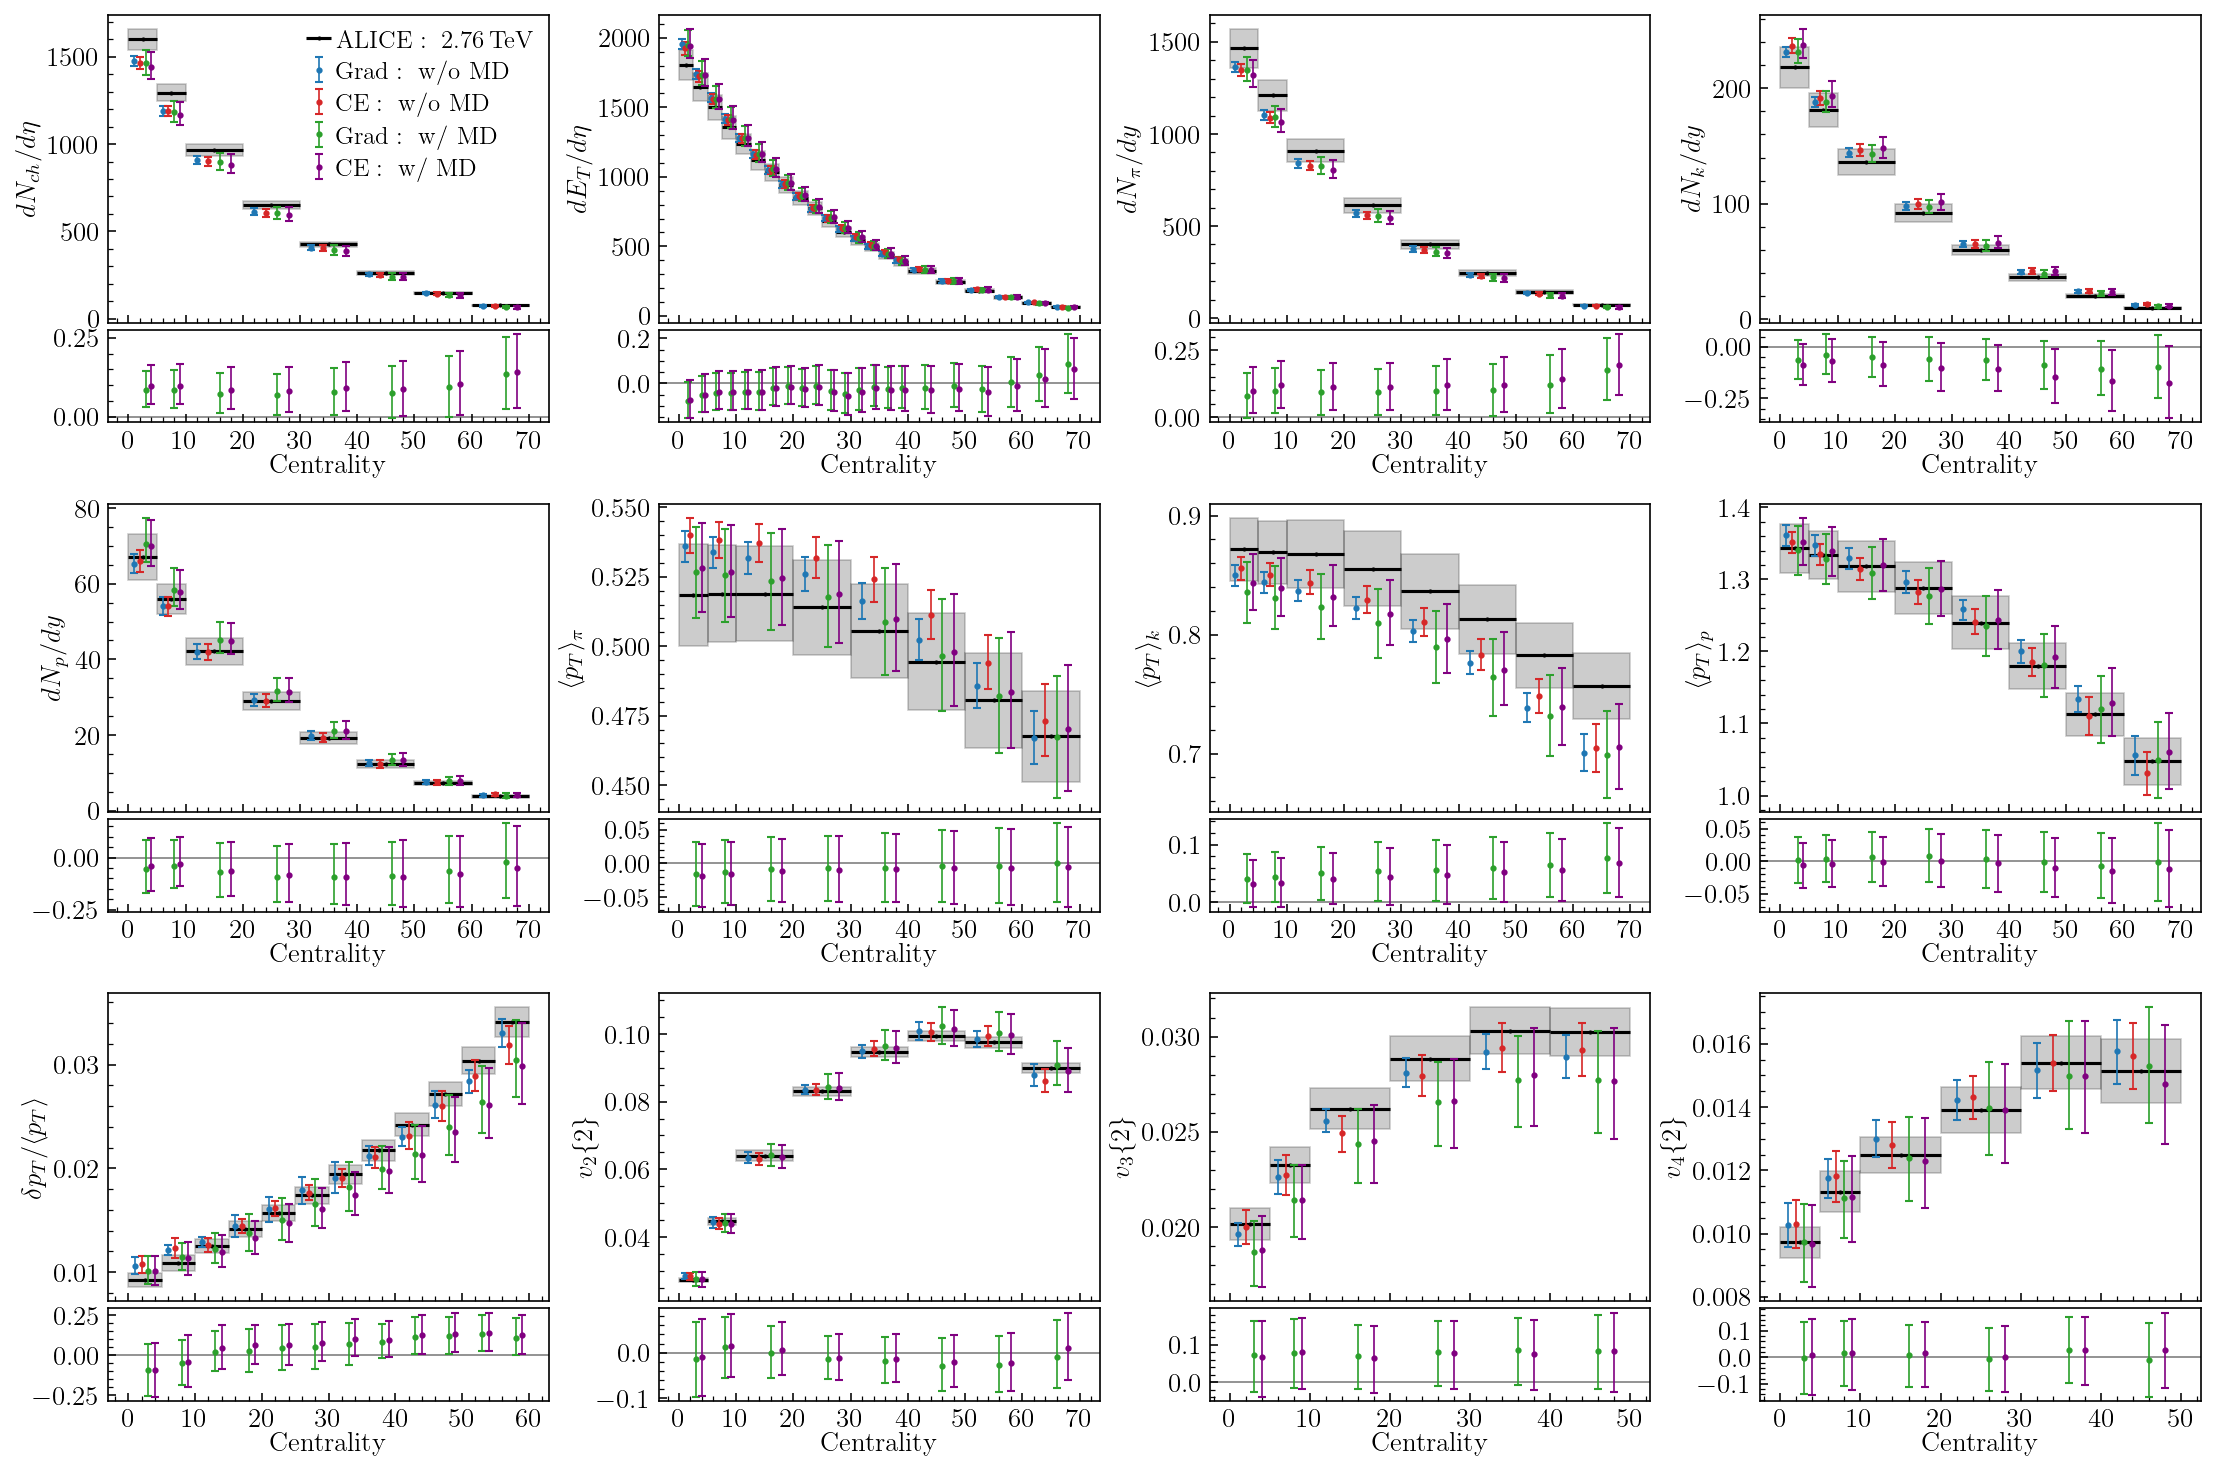

In [10]:
# plot model predictions. w/ and w/o MD for both Grad and CE

colors = ['tab:blue', 'tab:red', 'tab:green', '#800080']
legends = [ 
    r'$\mathrm{ALICE}:\ 2.76\, \mathrm{TeV}$',
    r"$\mathrm{Grad:\ w/o\ MD}$",
    r"$\mathrm{CE:\ w/o\ MD}$",
    r"$\mathrm{Grad:\ w/\ MD}$",
    r"$\mathrm{CE:\ w/\ MD}$",
]

# Quantiles: 50, 2.5, 97.5, 16, 84
quantiles1 = np.loadtxt('mcmc_data/PbPb2760/Grad/all_obs/wo_MD/quantiles_40000_model.txt')
quantiles2 = np.loadtxt('mcmc_data/PbPb2760/CE/all_obs/wo_MD/quantiles_40000_model.txt')
quantiles3 = np.loadtxt('mcmc_data/PbPb2760/Grad/all_obs/w_MD/quantiles_40000_model.txt')
quantiles4 = np.loadtxt('mcmc_data/PbPb2760/CE/all_obs/w_MD/quantiles_40000_model.txt')
quantiles_list = [quantiles1, quantiles2, quantiles3, quantiles4]

plot_obs(experimental_data, obs_bins, quantiles_list, colors, obs_labels, legends, 
         fig_name='plots/obs.pdf', error='show', error_all = 2)


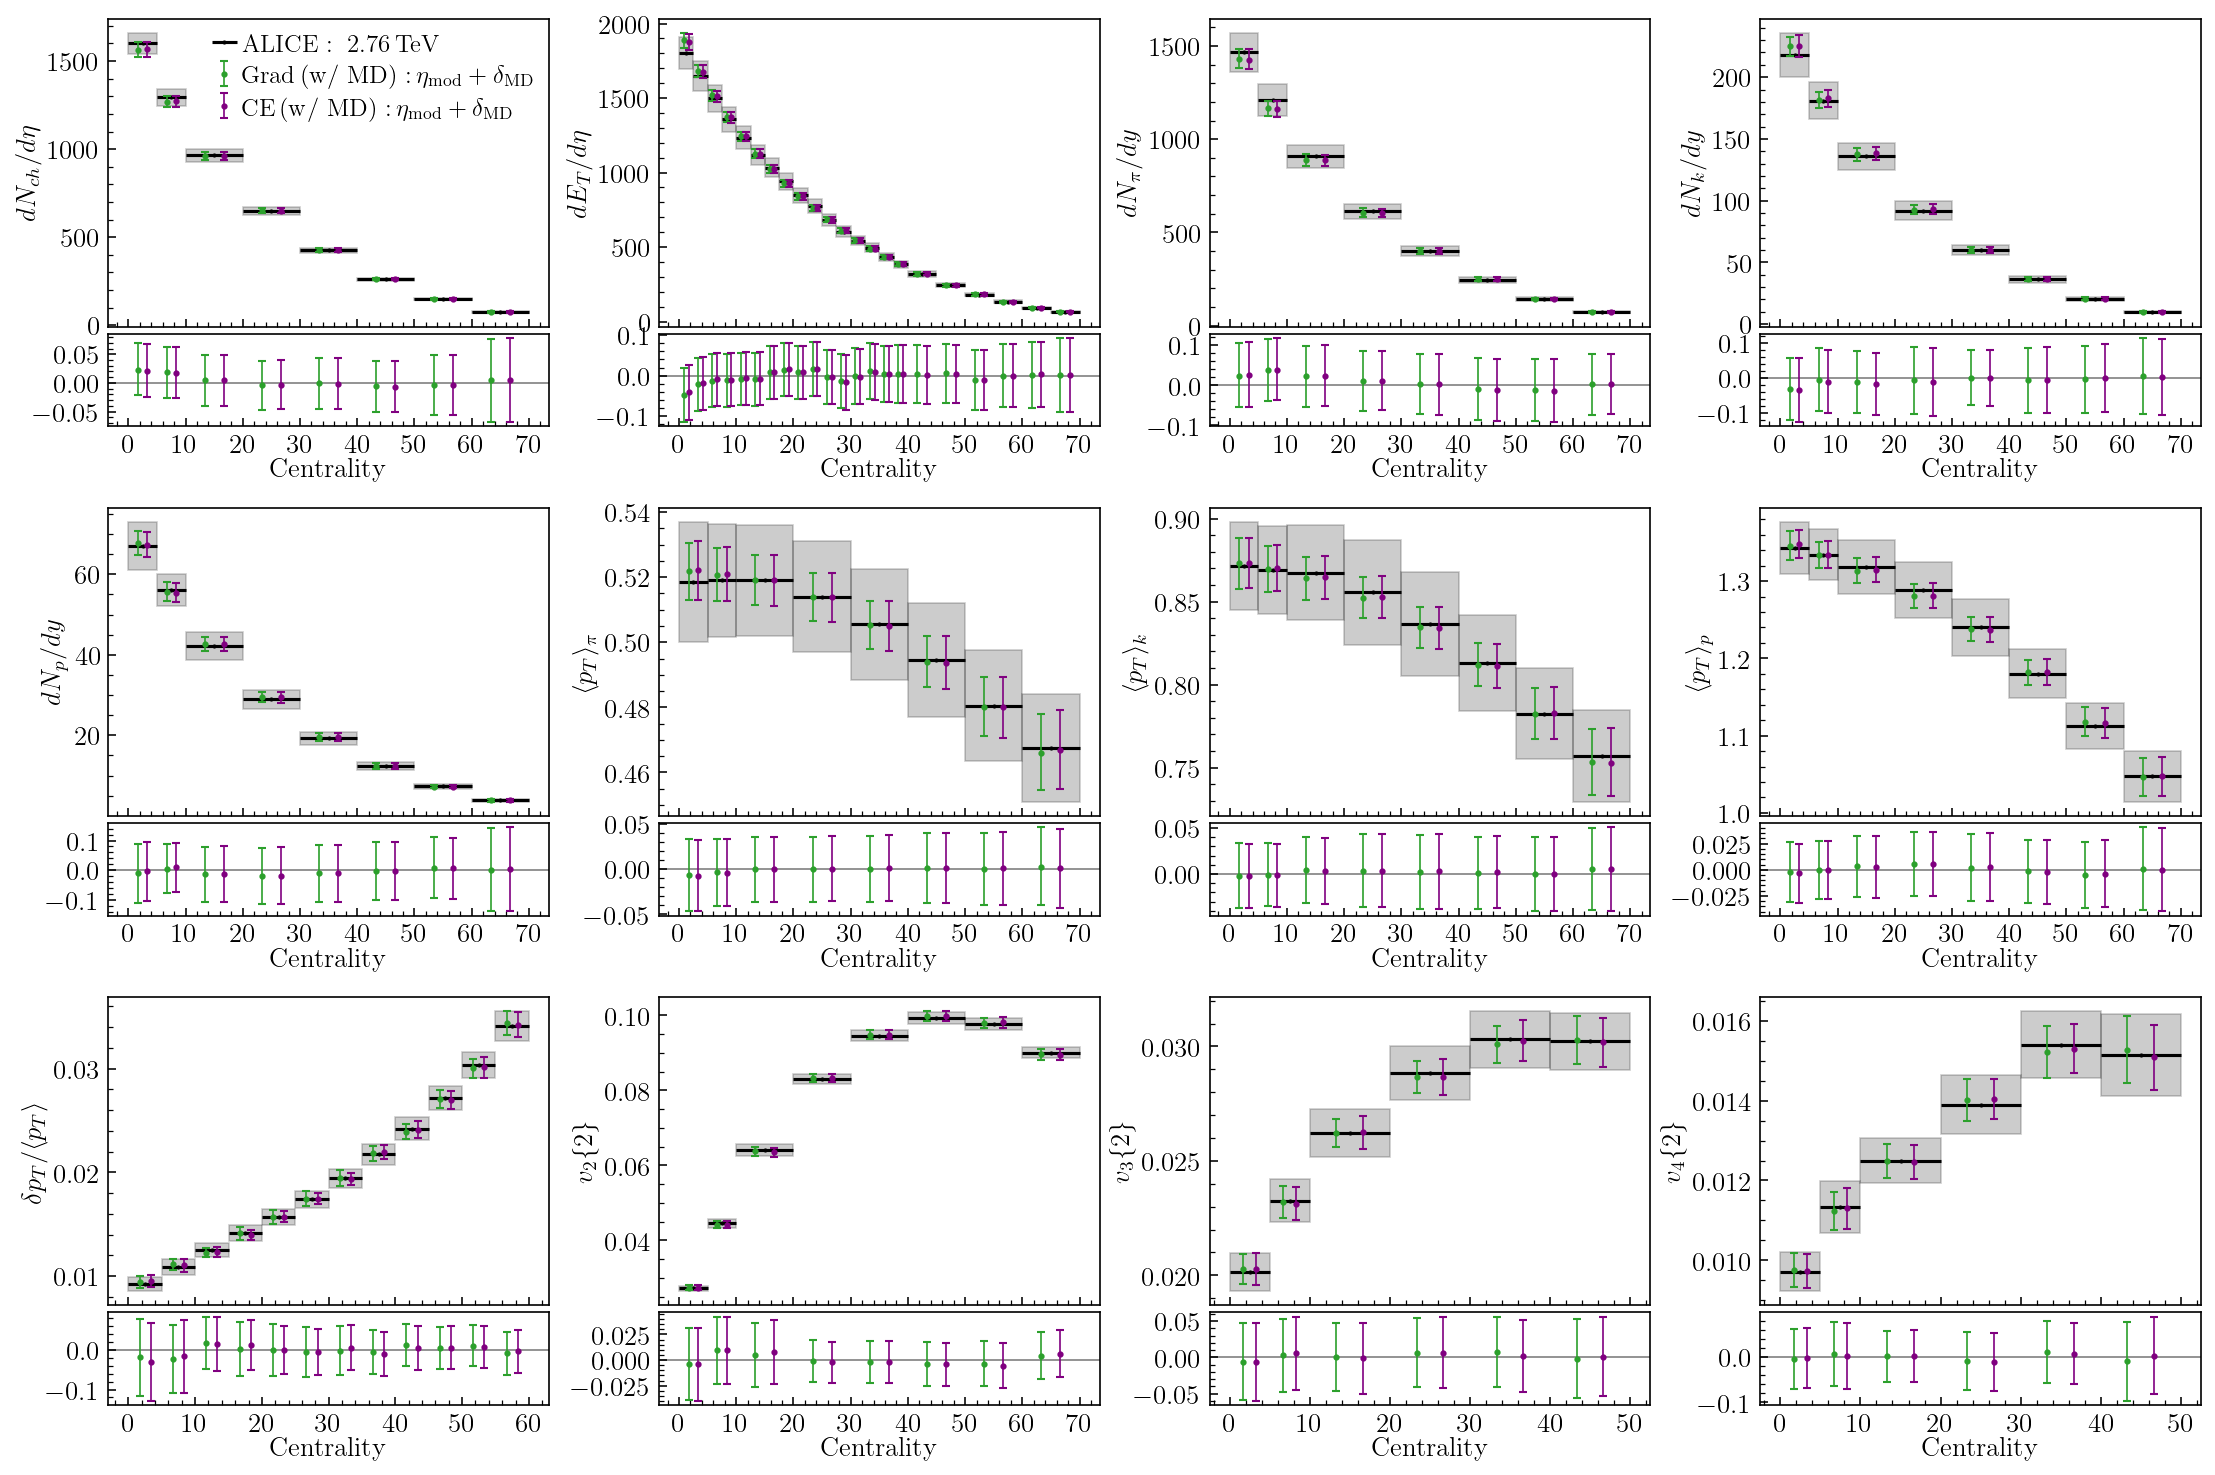

In [11]:
# plot model + delta (GP) predictions with both Grad and CE

quantiles1 = np.loadtxt('mcmc_data/PbPb2760/Grad/all_obs/w_MD/quantiles_40000_modelPlusGP.txt')
quantiles2 = np.loadtxt('mcmc_data/PbPb2760/CE/all_obs/w_MD/quantiles_40000_modelPlusGP.txt')
quantiles_list = [quantiles1, quantiles2]

expmean = np.abs(experimental_data[:,0])
quantiles_error = [quantiles1/expmean, quantiles2/expmean]

del quantiles1, quantiles2, expmean

colors = ['tab:green', '#800080']
legends = [ 
    r'$\mathrm{ALICE}:\ 2.76\, \mathrm{TeV}$',
    r"$\mathrm{Grad\, (w/\ MD):\,} \eta_{\rm mod} + \delta_{\rm MD}$",
    r"$\mathrm{CE\, (w/\ MD):\,} \eta_{\rm mod} + \delta_{\rm MD}$",
]

plot_obs(experimental_data, obs_bins, quantiles_list, colors, obs_labels, legends, 
         fig_name='plots/obs_modelPlusDelta.pdf', error='show')


# Calibration with $dN_{ch}/d\eta$, $dE_T/d\eta$, $v_2\{2\}$, $v_3\{2\}$, $v_4\{2\}$


## without MD

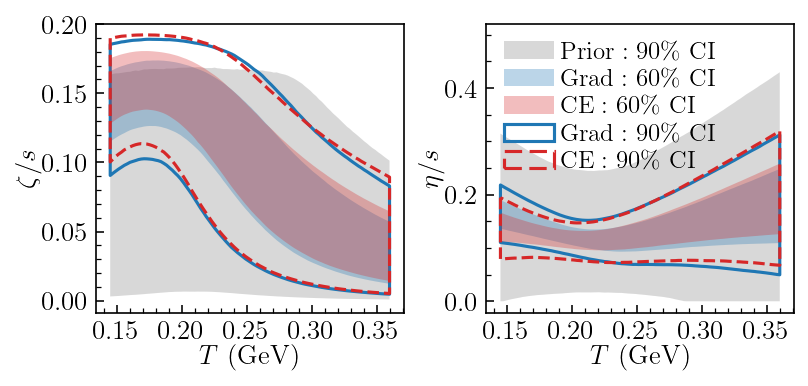

In [12]:
colors = ['tab:blue', 'tab:red']     # 'tab:orange'
linestyle = ['-', '--']
labels = [r"$\mathrm{Grad:}\ 60\%\ \mathrm{CI}$", r"$\mathrm{CE:}\ 60\%\ \mathrm{CI}$",
          r"$\mathrm{Grad:}\ 90\%\ \mathrm{CI}$", r"$\mathrm{CE:}\ 90\%\ \mathrm{CI}$"]

samples_wo_MD_Grad = np.load(f'mcmc_data/PbPb2760/Grad/dNch_dET_vn/wo_MD/pocomc_chain_40000.npy') #1
samples_wo_MD_CE = np.load(f'mcmc_data/PbPb2760/CE/dNch_dET_vn/wo_MD/pocomc_chain_40000.npy') #2

# slice to get samples for eta
amin, amax = 7, 11    # eta param : 7:11
param_bounds_eta = model_param_bounds[amin:amax]

samples1 = samples_wo_MD_Grad[:, amin:amax]
samples2 = samples_wo_MD_CE[:, amin:amax]
samples_eta = [samples1, samples2]

# slice to get samples for zeta
amin, amax = 11, 15   # zeta param : 11:15
param_bounds_zeta = model_param_bounds[amin:amax]

samples1 = samples_wo_MD_Grad[:, amin:amax]
samples2 = samples_wo_MD_CE[:, amin:amax]
samples_zeta = [samples1, samples2]

plot_eta_zeta(samples_eta=samples_eta, samples_zeta=samples_zeta, 
              eta_s=eta_over_s, zeta_s=zeta_over_s, 
              param_bounds_eta=param_bounds_eta, param_bounds_zeta=param_bounds_zeta, 
              colors=colors, labels=labels, linestyle=linestyle, fig_name='plots/eta_zeta_woMD_dNch_dET_vn.pdf')


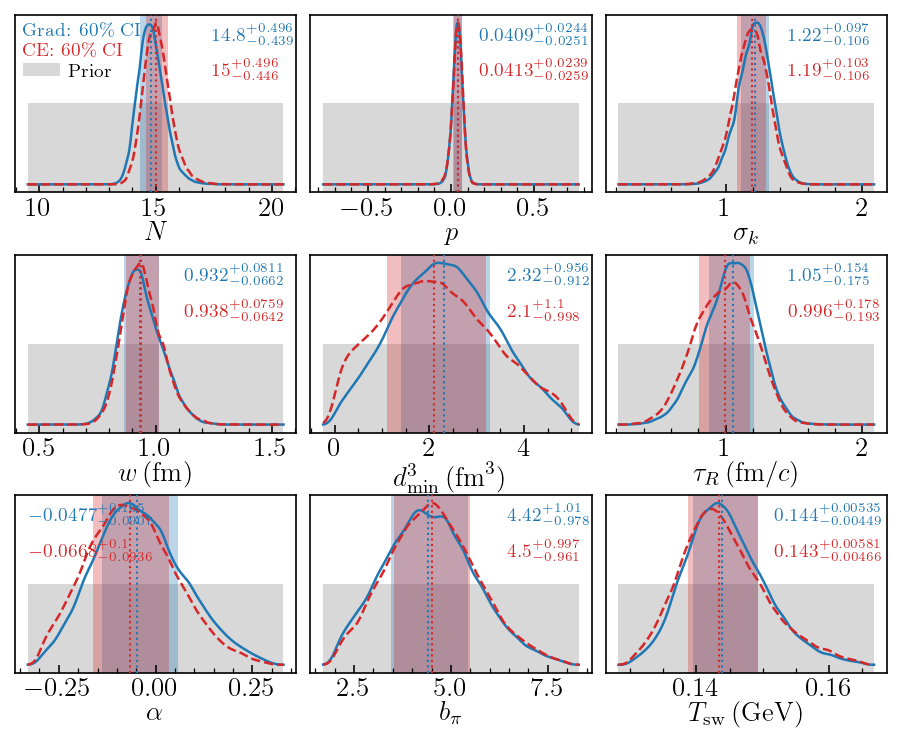

In [13]:
delta = model_param_bounds[:, 1] - model_param_bounds[:, 0]
# Extend the bounds by 5% on each side
extended_bounds = np.column_stack((
    model_param_bounds[:, 0] - 0.05 * delta,
    model_param_bounds[:, 1] + 0.05 * delta
))

samples = [samples_wo_MD_Grad, samples_wo_MD_CE]
mod_param_index = [0,1,2,3,4,5,6,15,16]

param_lab = [r'$N$', r'$p$', r'$\sigma_k$', r'$w\,({\rm fm})$', r'$d^3_{\rm min}\,({\rm fm}^3)$', 
             r'$\tau_R\,({\rm fm}/c)$', r'$\alpha$', r'$b_\pi$', r'$T_{\rm sw}\, ({\rm GeV})$']

plot_model_param(samples=samples, mod_param_index=mod_param_index, model_param_bounds=extended_bounds,
                 param_lab=param_lab, colors=colors, linestyle=linestyle, labels=labels, fig_name = 'plots/param_woMD_dNch_dET_vn.pdf')


In [14]:
# # corner plots ---->

# figure = corner.corner(
#     samples_wo_MD_Grad,
#     labels=allparam_lab,          # optional: parameter labels
#     quantiles=[0.16, 0.5, 0.84],  # show median + 1σ credible interval
#     show_titles=True,             # show mean/σ above diagonal plots
#     title_fmt=".3f",              # formatting for the stats
#     color="tab:blue",             # color for histograms
#     # bins=30,                    # number of bins
#     smooth=1.0,                   # KDE smoothing
# )

# figure.savefig("plots/corner_Grad_woMD_dNch_dET_vn.pdf", bbox_inches="tight", dpi=100)
# plt.show()

# figure = corner.corner(
#     samples_wo_MD_CE,
#     labels=allparam_lab,          # optional: parameter labels
#     quantiles=[0.16, 0.5, 0.84],  # show median + 1σ credible interval
#     show_titles=True,             # show mean/σ above diagonal plots
#     title_fmt=".3f",              # formatting for the stats
#     color="tab:red",              # color for histograms
#     # bins=30,                    # number of bins
#     smooth=1.0,                   # KDE smoothing
# )

# figure.savefig("plots/corner_CE_woMD_dNch_dET_vn.pdf", bbox_inches="tight", dpi=100)
# plt.show()


## with MD

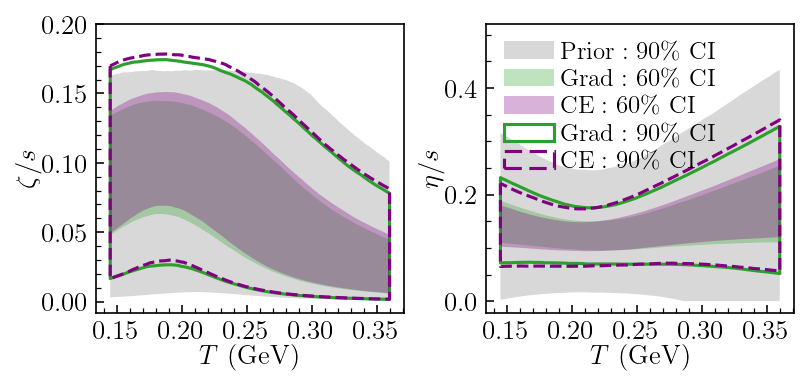

In [15]:
colors = ['tab:green', '#800080']     # 'tab:orange' 
linestyle = ['-', '--']
labels = [r"$\mathrm{Grad:}\ 60\%\ \mathrm{CI}$", r"$\mathrm{CE:}\ 60\%\ \mathrm{CI}$",
          r"$\mathrm{Grad:}\ 90\%\ \mathrm{CI}$", r"$\mathrm{CE:}\ 90\%\ \mathrm{CI}$"]

samples_w_MD_Grad = np.load(f'mcmc_data/PbPb2760/Grad/dNch_dET_vn/w_MD/pocomc_chain_40000.npy') #1
samples_w_MD_CE = np.load(f'mcmc_data/PbPb2760/CE/dNch_dET_vn/w_MD/pocomc_chain_40000.npy') #2

# slice to get samples for eta
amin, amax = 7, 11    # eta param : 7:11
param_bounds_eta = model_param_bounds[amin:amax]

samples1 = samples_w_MD_Grad[:, amin:amax]
samples2 = samples_w_MD_CE[:, amin:amax]
samples_eta = [samples1, samples2]

# slice to get samples for zeta
amin, amax = 11, 15   # zeta param : 11:15
param_bounds_zeta = model_param_bounds[amin:amax]

samples1 = samples_w_MD_Grad[:, amin:amax]
samples2 = samples_w_MD_CE[:, amin:amax]
samples_zeta = [samples1, samples2]

plot_eta_zeta(samples_eta=samples_eta, samples_zeta=samples_zeta, 
              eta_s=eta_over_s, zeta_s=zeta_over_s, 
              param_bounds_eta=param_bounds_eta, param_bounds_zeta=param_bounds_zeta, 
              colors=colors, labels=labels, linestyle=linestyle, fig_name='plots/eta_zeta_wMD_dNch_dET_vn.pdf')


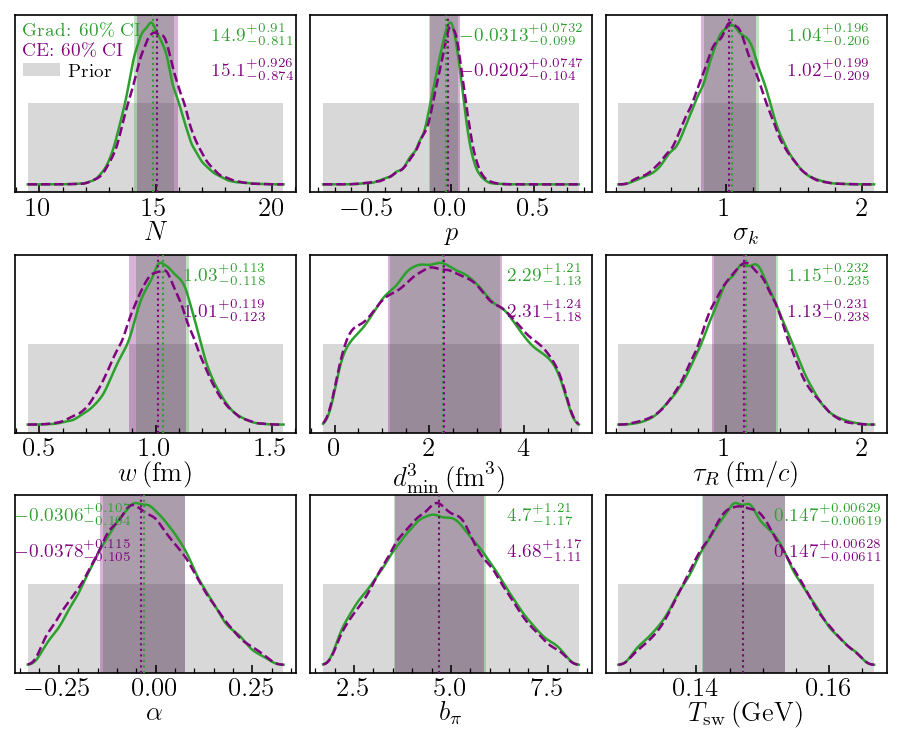

In [16]:
delta = model_param_bounds[:, 1] - model_param_bounds[:, 0]
# Extend the bounds by 5% on each side
extended_bounds = np.column_stack((
    model_param_bounds[:, 0] - 0.05 * delta,
    model_param_bounds[:, 1] + 0.05 * delta
))

samples = [samples_w_MD_Grad, samples_w_MD_CE]
mod_param_index = [0,1,2,3,4,5,6,15,16]

pos = [0.7, 0.533, 0.65, 0.6, 0.7, 0.65, 0.0, 0.7, 0.6]

param_lab = [r'$N$', r'$p$', r'$\sigma_k$', r'$w\,({\rm fm})$', r'$d^3_{\rm min}\,({\rm fm}^3)$', 
             r'$\tau_R\,({\rm fm}/c)$', r'$\alpha$', r'$b_\pi$', r'$T_{\rm sw}\, ({\rm GeV})$']

plot_model_param(samples=samples, mod_param_index=mod_param_index, model_param_bounds=extended_bounds,
                 param_lab=param_lab, colors=colors, linestyle=linestyle, labels=labels, fig_name = 'plots/param_wMD_dNch_dET_vn.pdf', pos=pos)


In [17]:
# # Corner plots for model parameters --> 

# figure = corner.corner(
#     samples_w_MD_Grad[:,:17],
#     labels=allparam_lab,          # optional: parameter labels
#     quantiles=[0.16, 0.5, 0.84],  # show median + 1σ credible interval
#     show_titles=True,             # show mean/σ above diagonal plots
#     title_fmt=".3f",              # formatting for the stats
#     color="tab:green",            # color for histograms
#     # bins=30,                    # number of bins
#     smooth=1.0,                   # KDE smoothing
# )

# figure.savefig("plots/corner_Grad_wMD_dNch_dET_vn.pdf", bbox_inches="tight", dpi=100)
# plt.show()

# figure = corner.corner(
#     samples_w_MD_CE[:,:17],
#     labels=allparam_lab,          # optional: parameter labels
#     quantiles=[0.16, 0.5, 0.84],  # show median + 1σ credible interval
#     show_titles=True,             # show mean/σ above diagonal plots
#     title_fmt=".3f",              # formatting for the stats
#     color="#800080",              # color for histograms
#     # bins=30,                    # number of bins
#     smooth=1.0,                   # KDE smoothing
# )

# figure.savefig("plots/corner_CE_wMD_dNch_dET_vn.pdf", bbox_inches="tight", dpi=100)
# plt.show()


## Plot observable predictions

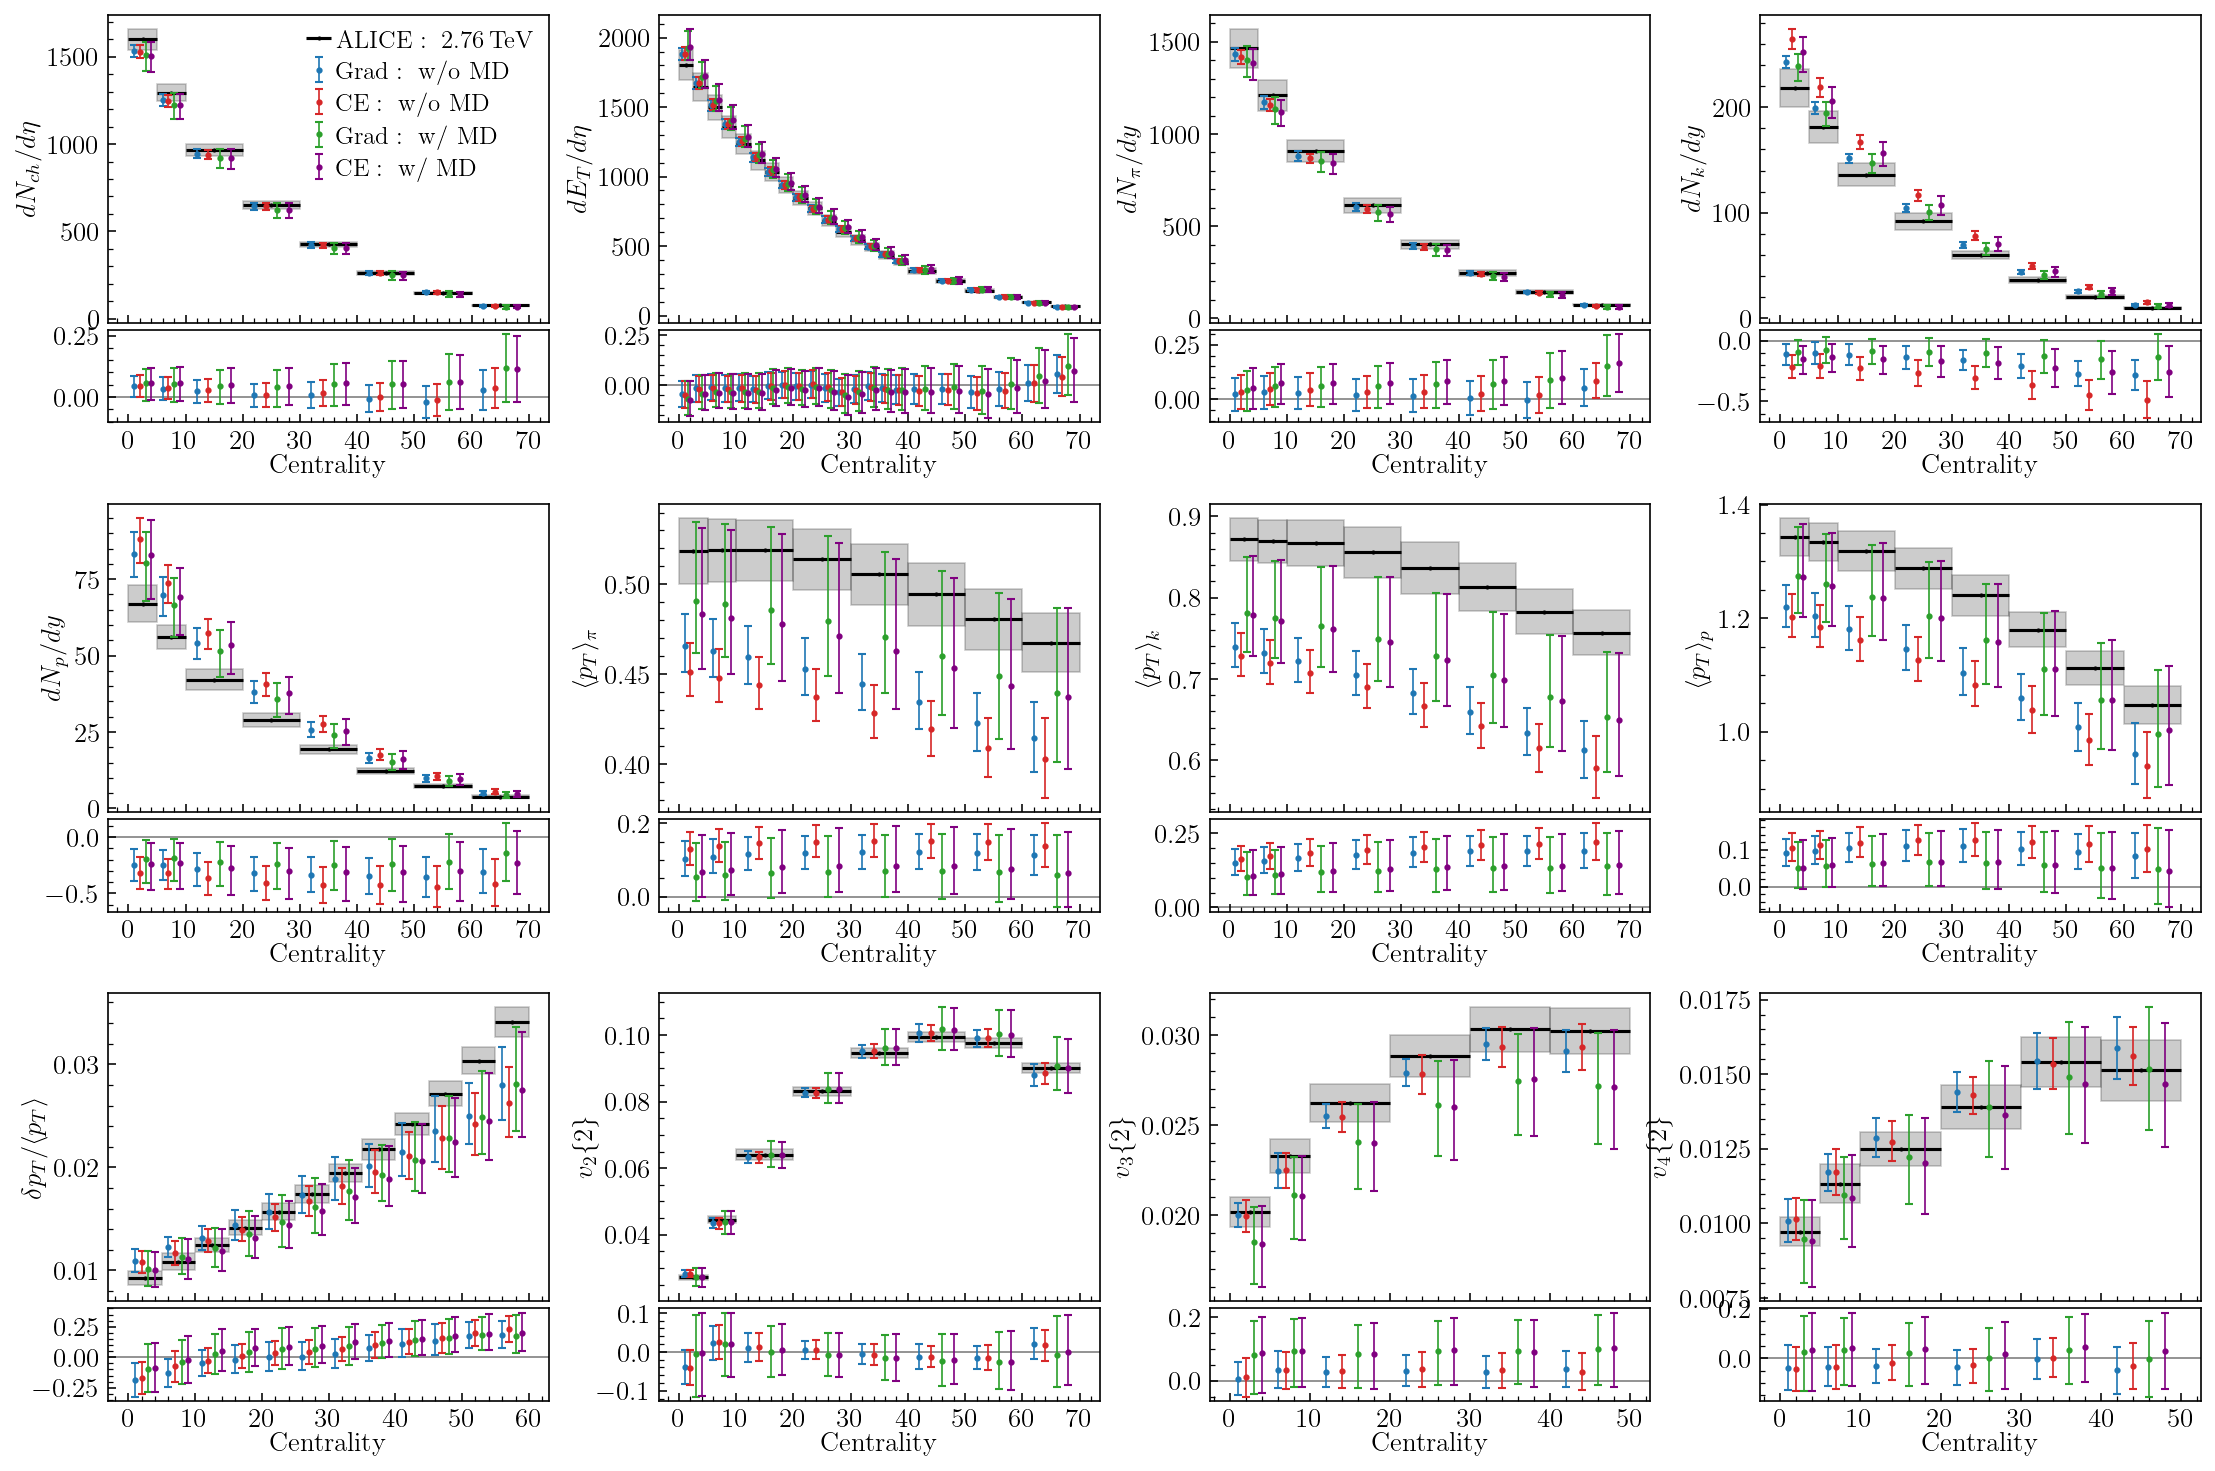

In [18]:
# plot model predictions. w/ and w/o MD for both Grad and CE

colors = ['tab:blue', 'tab:red', 'tab:green', '#800080']
legends = [ 
    r'$\mathrm{ALICE}:\ 2.76\, \mathrm{TeV}$',
    r"$\mathrm{Grad:\ w/o\ MD}$",
    r"$\mathrm{CE:\ w/o\ MD}$",
    r"$\mathrm{Grad:\ w/\ MD}$",
    r"$\mathrm{CE:\ w/\ MD}$",
]

# Quantiles: 50, 2.5, 97.5, 16, 84
quantiles1 = np.loadtxt('mcmc_data/PbPb2760/Grad/dNch_dET_vn/wo_MD/quantiles_40000_model.txt')
quantiles2 = np.loadtxt('mcmc_data/PbPb2760/CE/dNch_dET_vn/wo_MD/quantiles_40000_model.txt')
quantiles3 = np.loadtxt('mcmc_data/PbPb2760/Grad/dNch_dET_vn/w_MD/quantiles_40000_model.txt')
quantiles4 = np.loadtxt('mcmc_data/PbPb2760/CE/dNch_dET_vn/w_MD/quantiles_40000_model.txt')
quantiles_list = [quantiles1, quantiles2, quantiles3, quantiles4]

plot_obs(experimental_data, obs_bins, quantiles_list, colors, obs_labels, legends, 
         fig_name='plots/obs_dNch_dET_vn.pdf', error='show')
